<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/ML_off_target_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# ======================================================
# Simple CNNCrispr Off-Target Prediction Workflow
# ======================================================

import pandas as pd

# ======================================================
# Step 1: Guide RNA
# ======================================================

guide_rna = "GAGTCCGAGCAGAAGAAGAA"

print("Guide RNA:", guide_rna)

# ======================================================
# Step 2: Candidate Off-Target Sequences
#(Normally generated by Cas-OFFinder)
# ======================================================
# ======================================================

off_targets = [
"GAGTCCGAGCAGAAGAAGAA",   # Perfect match
"GAGTCCGAGGAGAAGAAGAA",   # 1 mismatch
"GAGTCCGAGTAGAAGAAGAA",    # 2 mismatches
"GAGTCCGCGCAGAAGAAGAT", # 3 mismatches
"TAGTCCGCGCAGAAGAAGTT" # 5 mismatches
]




Guide RNA: GAGTCCGAGCAGAAGAAGAA


In [8]:
# =====================================================
# Step 3: Function to Count Mismatches

def count_mismatches(gRNA, target):
  mismatch = 0
  for a, b in zip(gRNA, target):
    if a != b:
      mismatch += 1
  return mismatch

## =====================================================

# Step 4: Simple Off-Target Score
# (Teaching Purpose Only)
# Higher mismatches = Lower score
# # =====================================================


results = []

for seq in off_targets:

  mismatch = count_mismatches(guide_rna, seq)

  score = max(0, 1 - mismatch/20)

  results.append([seq, mismatch, round(score,3)])
# # =====================================================

# Step 5: Create DataFrame
# # =====================================================

df  = pd.DataFrame(
    results,
    columns=["Off_Target_Sequence", "Mismatch", "Predicted_Score"]
)



In [9]:
# # =====================================================

# Step 6: Rank Scores
# # =====================================================
df = df.sort_values(
    by ="Predicted_Score",
    ascending=False
)
print("\n Predicted Off-Target Scores\n")
print(df)


 Predicted Off-Target Scores

    Off_Target_Sequence  Mismatch  Predicted_Score
0  GAGTCCGAGCAGAAGAAGAA         0             1.00
1  GAGTCCGAGGAGAAGAAGAA         1             0.95
2  GAGTCCGAGTAGAAGAAGAA         1             0.95
3  GAGTCCGCGCAGAAGAAGAT         2             0.90
4  TAGTCCGCGCAGAAGAAGTT         4             0.80


In [10]:
# # =====================================================

# Step 7 : Save Results
# # =====================================================

df.to_csv("CNNCrisper_results.csv",index=False)
print("\nResults saved as CNNCrisper_results.csv")


Results saved as CNNCrisper_results.csv


In [18]:
# Clone the repository
!git clone https://github.com/LQYoLH/CnnCrispr.git


Cloning into 'CnnCrispr'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 122 (delta 10), reused 0 (delta 0), pack-reused 84 (from 1)
Receiving objects: 100% (122/122), 24.81 MiB | 20.62 MiB/s, done.
Resolving deltas: 100% (38/38), done.


In [19]:
#View repository contents
!find CnnCrispr -type f

CnnCrispr/CnnCrispr_final/output_example.txt
CnnCrispr/CnnCrispr_final/CnnCrispr.py
CnnCrispr/CnnCrispr_final/Model_save/CnnCrispr_weights.h5
CnnCrispr/CnnCrispr_final/Model_save/test
CnnCrispr/CnnCrispr_final/Model_save/CnnCrispr_model.h5
CnnCrispr/CnnCrispr_final/Encoded_data/test1
CnnCrispr/CnnCrispr_final/Encoded_data/Class/K562_off_Glove.txt
CnnCrispr/CnnCrispr_final/Encoded_data/Class/hek293_off_Glove.txt
CnnCrispr/CnnCrispr_final/Encoded_data/Class/off_Glove.txt
CnnCrispr/CnnCrispr_final/Encoded_data/Class/cooccurrence_5.csv
CnnCrispr/CnnCrispr_final/Encoded_data/Class/keras_GloVeVec_5_100_10000.csv
CnnCrispr/CnnCrispr_final/input_example.txt
CnnCrispr/images/Fig. 1.tif
CnnCrispr/images/Fig. 6.tif
CnnCrispr/images/Fig. 5.tif
CnnCrispr/images/Fig. 2.tif
CnnCrispr/images/Fig. 3.tif
CnnCrispr/images/Fig. 4.tif
CnnCrispr/offtarget_data.rar
CnnCrispr/offtarget_data/Regression/off_data_twoset.xlsx
CnnCrispr/offtarget_data/Regression/off_data_reg.xlsx
CnnCrispr/offtarget_data/test
CnnC

In [20]:
import os
for root, dirs, files in os.walk("CnnCrispr"):
  for file in files:
    if file.endswith((".csv",".txt",".xslx")):
      print(os.path.join(root, file))

CnnCrispr/CnnCrispr_final/output_example.txt
CnnCrispr/CnnCrispr_final/input_example.txt
CnnCrispr/CnnCrispr_final/Encoded_data/Class/K562_off_Glove.txt
CnnCrispr/CnnCrispr_final/Encoded_data/Class/hek293_off_Glove.txt
CnnCrispr/CnnCrispr_final/Encoded_data/Class/off_Glove.txt
CnnCrispr/CnnCrispr_final/Encoded_data/Class/cooccurrence_5.csv
CnnCrispr/CnnCrispr_final/Encoded_data/Class/keras_GloVeVec_5_100_10000.csv


In [22]:
# ===============================================
# Crispr Real Dataset Analysis
# ===============================================
import pandas as pd
import matplotlib.pyplot as plt
 # ------------------------------------------------
 # Load Dataset
 # --------------------------------------------------
file_path = "CnnCrispr/offtarget_data/Classification/off_data_class.xlsx"
df = pd.read_excel(file_path)

print("="*60)
print("CNNCrispr Classifcation Dataset")
print("="*60)

print(df.head())


CNNCrispr Classifcation Dataset
   sg9  AAATGAGAAGAAGAGGCACAGGG  GCATGAGAAGAAGAGACATAGCC  0
0  sg8  GGGTGGGGGGAGTTTGCTCCTGG  GTGGGGGTAGAGTTTGCTCCAGG  1
1  sg8  GGGTGGGGGGAGTTTGCTCCTGG  GCGTGGGGGGTGTTTGCTCCCGG  1
2  sg8  GGGTGGGGGGAGTTTGCTCCTGG  CGGGGGAGGGAGTTTGCTCCTGG  1
3  sg1  AACACCAGTGAGTAGAGCGGAGG  AACACCAGCGAGTAGAGCGGAGG  1
4  sg6  ATGAACACCAGTGAGTAGAGCGG  ATGAACACCAGCGAGTAGAGCGG  1


In [23]:
# ==========================================================
# Dataset Information
# ==========================================================
print("\nShape")
print(df.shape)
print("\nColumns")
print(df.columns.tolist())
print("\nInformation")
print(df.info())
print("\nMissing Values")
print(df.isnull().sum())


Shape
(73418, 4)

Columns
['sg9', 'AAATGAGAAGAAGAGGCACAGGG', 'GCATGAGAAGAAGAGACATAGCC', 0]

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73418 entries, 0 to 73417
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   sg9                      73418 non-null  object
 1   AAATGAGAAGAAGAGGCACAGGG  73418 non-null  object
 2   GCATGAGAAGAAGAGACATAGCC  73418 non-null  object
 3   0                        73418 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.2+ MB
None

Missing Values
sg9                        0
AAATGAGAAGAAGAGGCACAGGG    0
GCATGAGAAGAAGAGACATAGCC    0
0                          0
dtype: int64


In [24]:
#===============================================================
# Basic Statitics
#===============================================================

print("\nSummary Statistics")
print(df.describe(include="all"))



Summary Statistics
          sg9  AAATGAGAAGAAGAGGCACAGGG  GCATGAGAAGAAGAGACATAGCC             0
count   73418                    73418                    73418  73418.000000
unique     18                       29                    73418           NaN
top       sg8  GGTGAGTGAGTGTGTGCGTGTGG  TCAGCCCCAAAGCCTGGCCTGTT           NaN
freq    25568                    23306                        1           NaN
mean      NaN                      NaN                      NaN      0.008445
std       NaN                      NaN                      NaN      0.091507
min       NaN                      NaN                      NaN      0.000000
25%       NaN                      NaN                      NaN      0.000000
50%       NaN                      NaN                      NaN      0.000000
75%       NaN                      NaN                      NaN      0.000000
max       NaN                      NaN                      NaN      1.000000


In [25]:
# ======================================================================
# Label Distribution
# =====================================================================

# Replace "label" with the actual column name if different
label_column = "label"
if label_column in df.columns:
  print(df[label_column].value_counts())
  plt.figure(figsize=(6, 4))
  df[label_column].value_counts().plot(kind="bar")
  plt.xlabel("Class")
  plt.ylabel("Count")
  plt.title("Postivie vs Negative Samples")
  plt.show()
else:
  print("Label column not found.")

Label column not found.


In [26]:
# -------------------------------------------------------
# Sequence Columns
# ------------------------------------------------------
sequence_columns = []
for col in df.columns:
  if df[col].dtype == "object":
    sequence_columns.append(col)
print("\nPossible Sequence Columns")
print(sequence_columns)



Possible Sequence Columns
['sg9', 'AAATGAGAAGAAGAGGCACAGGG', 'GCATGAGAAGAAGAGACATAGCC']



Average Length Analysis for sg9
3.3049116020594407


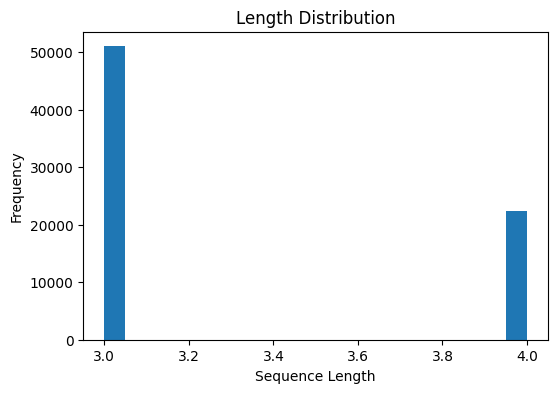


Average Length Analysis for AAATGAGAAGAAGAGGCACAGGG
23.0


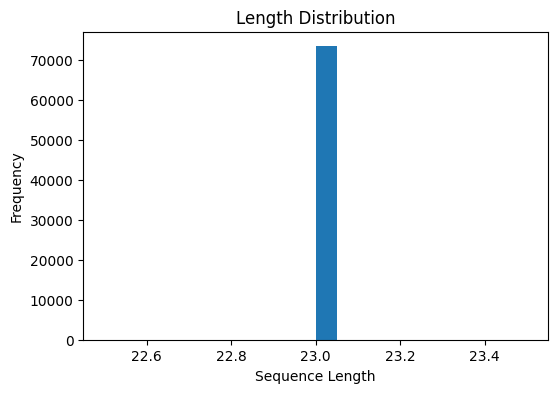


Average Length Analysis for GCATGAGAAGAAGAGACATAGCC
23.0


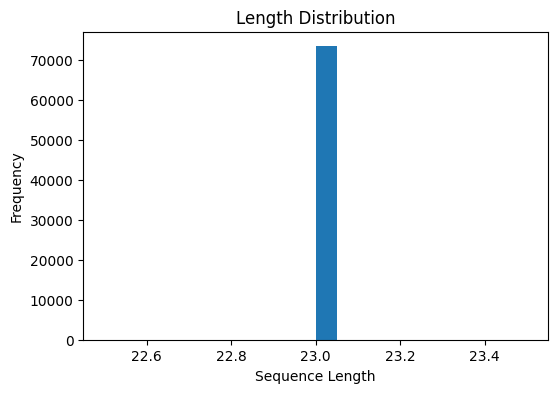

In [27]:
# -----------------------------------------------------------------
# Sequence Length Analysis
# -----------------------------------------------------------------
for col in sequence_columns:
  df[col+"_Length"] = df[col].astype(str).str.len()
  print(f"\nAverage Length Analysis for {col}")
  print(df[col+"_Length"].mean())
  plt.figure(figsize=(6,4))
  plt.hist(df[col+"_Length"],bins =20)
  plt.xlabel("Sequence Length")
  plt.ylabel("Frequency")
  plt.title(f"Length Distribution")
  plt.show()

In [28]:
# =======================================================
# GC Content
# =======================================================
def gc_content(sequence):
  sequence = str(sequence).upper()
  if len(sequence) == 0:
    return 0
  gc = sequence.count("G") + sequence.count("C")
  return gc/len(sequence)*100

for col in sequence_columns:
  df[col+"_GC"] = df[col].apply(gc_content)
  print(f"\nAverage GC Content Analysis for {col}")
  print(round(df[col+"_GC"].mean(),2))


Average GC Content Analysis for sg9
30.79

Average GC Content Analysis for AAATGAGAAGAAGAGGCACAGGG
59.81

Average GC Content Analysis for GCATGAGAAGAAGAGACATAGCC
53.65


In [29]:
# ============================================================
# Correlation
# ===========================================================
numeric_df = df.select_dtypes(include="number")
print("\nCorrelation Matrix")
print(numeric_df.corr())


Correlation Matrix
                                       0  sg9_Length  \
0                               1.000000    0.053657   
sg9_Length                      0.053657    1.000000   
AAATGAGAAGAAGAGGCACAGGG_Length       NaN         NaN   
GCATGAGAAGAAGAGACATAGCC_Length       NaN         NaN   
sg9_GC                         -0.053657   -1.000000   
AAATGAGAAGAAGAGGCACAGGG_GC      0.072564   -0.043959   
GCATGAGAAGAAGAGACATAGCC_GC      0.077856   -0.002050   

                                AAATGAGAAGAAGAGGCACAGGG_Length  \
0                                                          NaN   
sg9_Length                                                 NaN   
AAATGAGAAGAAGAGGCACAGGG_Length                             NaN   
GCATGAGAAGAAGAGACATAGCC_Length                             NaN   
sg9_GC                                                     NaN   
AAATGAGAAGAAGAGGCACAGGG_GC                                 NaN   
GCATGAGAAGAAGAGACATAGCC_GC                                 NaN   

  

In [30]:
# -----------------------------------------------------------------------
# Save Processed Dataset
# ----------------------------------------------------------------------
df.to_csv("Processed_CNNCrispr_Dataset.csv",index="False")
print("\nAnalysis Completed Successfully.")


Analysis Completed Successfully.
